In [5]:
import os
from dotenv import load_dotenv
from tavily import TavilyClient
from typing import Literal
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from deepagents import create_deep_agent

load_dotenv()

True

In [24]:
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [25]:
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str, max_results:int=5, topic: Literal["general", "sports", "news", "finance"]="general", include_raw_content:bool = True):
    """Run a web search"""
    return tavily_client.search(query, max_results=5, include_raw_content=include_raw_content, topic=topic)

In [42]:
model=init_chat_model("google_genai:gemini-3.5-flash-lite")
model

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.4'}}, profile={'name': 'Gemini 3.5 Flash Lite', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='gemini-3.5-flash-lite', temperature=None, client=<google.genai.client.Client object at 0x0000023DD5091940>, default_metadata=(), model_kwa

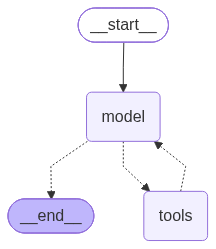

In [43]:
agent = create_agent( model=model, tools=[web_search])
agent

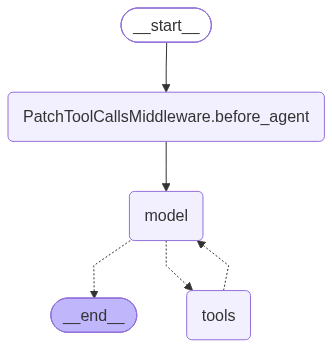

In [44]:
deep_agent = create_deep_agent(model=model, tools=[web_search], system_prompt="Act as a reasearcher")
deep_agent

In [45]:
result = deep_agent.invoke({"messages": [{"role": "user", "content": "What is deep agent?"}]})
result

{'messages': [HumanMessage(content='What is deep agent?', additional_kwargs={}, response_metadata={}, id='abf2f0b1-44c4-4ca5-882d-3c692a129887'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "deep agent AI definition framework"}'}, '__gemini_function_call_thought_signatures__': {'call_1515746': 'El4KXAERTTIP9/SnXzSnNDh364xLfmZTKHZnNvkf9Uw26KPjlBwd5/mPkg4a+fOYDVoL5OFOCB0GO0MF5WHygBZ31C5j4e+wTtygHmlqIsvj4czlNzVLPozbSAkXpfWr'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0064b-f8bb-7b71-9125-b212fff88980-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'deep agent AI definition framework'}, 'id': 'call_1515746', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2231, 'output_tokens': 20, 'total_tokens': 2251, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='Tool re

In [46]:
result["messages"][-1].content

[{'type': 'text',
  'text': 'A **Deep Agent** is an advanced class of AI agent built on top of Large Language Models (LLMs) and orchestration frameworks (such as LangChain and LangGraph) designed to autonomously tackle complex, multi-step, open-ended tasks. \n\nWhile traditional AI chatbots respond to one prompt at a time, and basic AI agents execute simple "Think-Act-Observe" loops (like standard ReAct agents), **deep agents** are engineered with advanced architectural patterns that mimic human problem-solving, deep research, and software engineering workflows.\n\n---\n\n### Key Characteristics of Deep Agents\n\n1. **Autonomous Planning and Task Decomposition**\n   * Instead of immediately executing a request linearly, a deep agent analyzes the goal, breaks it down into granular sub-tasks (often maintaining dynamic to-do lists or task queues), and maps out a execution strategy.\n\n2. **Hierarchical Multi-Agent Collaboration**\n   * Deep agents frequently utilize hierarchical or multi-

In [47]:
result['files']

{'/large_tool_results/call_1515746': {'content': '{"query": "deep agent AI definition framework", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.royalcyber.com/blogs/ai-services/deep-agent-ai", "title": "Deep Agent AI: The Next Evolution of AI Research", "content": "Deep Agents AI are an emerging class of AI systems – built on advanced large language models (LLMs) – that can autonomously tackle complex, multi-step tasks in a way traditional AI assistants cannot. Unlike a standard chatbot that answers one question at a time, a deep agent is capable of conducting multi-step research: it dynamically plans a series of actions, gathers information from numerous sources, and synthesizes the results into a coherent output. In essence, you give the agent a [...] At the core, a deep agent still uses an LLM (like GPT-4 or newer) to drive its behavior. The core algorithm is the familiar loop of an LLM reasoning and calling tools, often referred to as t

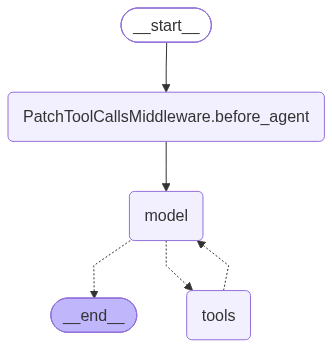

In [48]:
model = init_chat_model("google_genai:gemini-3.5-flash-lite")
agent = create_deep_agent(model=model)
agent

In [49]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='d0fec4c9-22dc-4aeb-9d19-699d790b7f71'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'grep', 'arguments': '{"pattern": "deepagent"}'}, '__gemini_function_call_thought_signatures__': {'call_1036231': 'El4KXAERTTIPXTEMrBt7rnIlmnKAEBHmIIi418a+lypqwi8AO6Z5LzNAIP/zg/dVfgScTTXr2LFgFCX/2fJgEqhlCAazBnruAwXpsFh5KvW8H66VslOZQ6sl+DWg1uvq'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0064c-fe76-7731-8155-a2d842461ca5-0', tool_calls=[{'name': 'grep', 'args': {'pattern': 'deepagent'}, 'id': 'call_1036231', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2135, 'output_tokens': 15, 'total_tokens': 2150, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='No matches found', name='grep', id='ba1e44d3-2532-4d93-b638-bf588e

In [50]:
research_instructions = """\
You are an expert researcher. Your job is to conduct \
thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='3da7b3fb-9373-4a64-9f72-801dd634b1ff'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'glob', 'arguments': '{"pattern": "*deepagent*"}'}, '__gemini_function_call_thought_signatures__': {'call_1445071': 'El4KXAERTTIPj7jMpCogXtbfELNP3eDyH8OSLyF47M/+brXam9Ti5E5A9cBtN+NcFucHEFWGJ/bVXU3PWqJHpop4K1VA3Xa4vWOgSiC5qcNxmo5qxms46NGDxSsWAwbr'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0064d-3173-7501-adee-a010631d14f2-0', tool_calls=[{'name': 'glob', 'args': {'pattern': '*deepagent*'}, 'id': 'call_1445071', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2157, 'output_tokens': 17, 'total_tokens': 2174, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='No files found', name='glob', id='350754ad-bb2b-453a-a2d2-c911

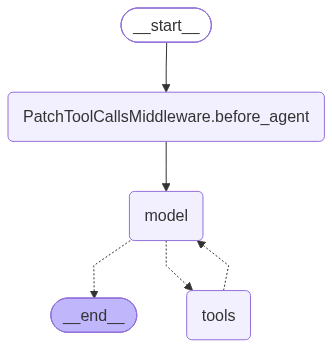

In [51]:
agent